## 1. Setup and Data Loading

In [41]:
# Install required libraries
%pip install xgboost scikit-learn pandas numpy matplotlib seaborn imbalanced-learn --quiet

Note: you may need to restart the kernel to use updated packages.


In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    roc_curve, precision_recall_curve, auc
)
import xgboost as xgb
from imblearn.over_sampling import SMOTE
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("✓ Libraries imported successfully")
print(f"XGBoost version: {xgb.__version__}")

✓ Libraries imported successfully
XGBoost version: 3.1.3


In [43]:
df = pd.read_csv('../data/processed/feature_engineered_with_SLM.csv')

print(f"Dataset shape: {df.shape}")
print(f"\nColumns: {len(df.columns)}")
print(f"\nTarget distribution:")
print(df['is_fraud'].value_counts())
print(f"\nFraud percentage: {df['is_fraud'].mean() * 100:.2f}%")

df.head()

Dataset shape: (1200, 33)

Columns: 33

Target distribution:
is_fraud
0    1119
1      81
Name: count, dtype: int64

Fraud percentage: 6.75%


,transaction_id,customer_id,transaction_datetime,country,channel,merchant_category,amount,device_trust_score,num_txn_24h_customer,previous_chargeback_count,...,txn_hour_count,txn_dayofweek_count,customer_mean_amount,customer_std_amount,amount_z_customer,is_risky_country,low_device_trust,high_amount_z,composite_risk_score,urgency_numeric
0,998,1000,2022-10-05 15:13:00,US,mobile_app,luxury,672.47,23.0,2,3,...,1,2,1931.283333,1662.07937,-0.757373,0,1,0,7.333333,2
1,953,1000,2023-02-05 06:18:18,US,web,gaming,2593.31,84.0,0,0,...,1,2,1931.283333,1662.07937,0.398312,0,0,0,3.555556,2
2,94,1000,2023-03-23 18:04:02,US,pos_terminal,electronics,302.22,70.0,3,1,...,1,2,1931.283333,1662.07937,-0.980136,0,0,0,4.000000,2
3,457,1000,2023-04-05 00:14:27,US,mobile_app,gaming,4395.07,24.0,0,2,...,1,2,1931.283333,1662.07937,1.482352,0,1,0,7.333333,2
4,1199,1000,2023-07-13 02:02:46,US,mobile_app,luxury,579.99,23.0,1,0,...,1,2,1931.283333,1662.07937,-0.813014,0,1,0,5.555556,0


## 2. Data Preprocessing

In [44]:
# Check for missing values
print("Missing values per column:")
missing = df.isnull().sum()
if missing.sum() > 0:
    print(missing[missing > 0])
else:
    print("No missing values found")

# Check data types
print(f"\nData types:")
print(df.dtypes.value_counts())

Missing values per column:
prev_txn_time           179
txn_7d_count           1200
customer_std_amount       1
amount_z_customer         1
dtype: int64

Data types:
int64      17
object      8
float64     8
Name: count, dtype: int64


In [45]:
# Select features for modeling
columns_to_drop = [
    'transaction_id', 'customer_id',
    'transaction_datetime', 'transaction_note',
    'prev_txn_time', "txn_7d_count"  #
]

df_model = df.copy()

# Drop unnecessary columns
df_model = df_model.drop(columns=[col for col in columns_to_drop if col in df_model.columns])

print(f"Features for modeling: {df_model.shape[1] - 1}")  # -1 for target
print(f"\nRemaining columns: {df_model.columns.tolist()}")

Features for modeling: 26

Remaining columns: ['country', 'channel', 'merchant_category', 'amount', 'device_trust_score', 'num_txn_24h_customer', 'previous_chargeback_count', 'is_fraud', 'slm_risk_score', 'slm_urgency', 'slm_anomaly_category', 'txn_hour', 'txn_dayofweek', 'txn_week', 'is_weekend', 'is_night', 'txn_gap_minutes', 'txn_hour_count', 'txn_dayofweek_count', 'customer_mean_amount', 'customer_std_amount', 'amount_z_customer', 'is_risky_country', 'low_device_trust', 'high_amount_z', 'composite_risk_score', 'urgency_numeric']


In [46]:
categorical_cols = df_model.select_dtypes(include=['object']).columns.tolist()

# Remove target variable if it's in the list
if 'is_fraud' in categorical_cols:
    categorical_cols.remove('is_fraud')

print(f"Detected categorical columns: {categorical_cols}\n")

# Encode categorical variables
label_encoders = {}

for col in categorical_cols:
    if col in df_model.columns:
        le = LabelEncoder()
        df_model[col] = le.fit_transform(df_model[col].astype(str))
        label_encoders[col] = le
        print(f"Encoded {col}: {len(le.classes_)} unique values")

print("\n Categorical encoding complete")

Detected categorical columns: ['country', 'channel', 'merchant_category', 'slm_urgency', 'slm_anomaly_category']

Encoded country: 8 unique values
Encoded channel: 3 unique values
Encoded merchant_category: 5 unique values
Encoded slm_urgency: 3 unique values
Encoded slm_anomaly_category: 5 unique values

 Categorical encoding complete


In [47]:
print("Data types after encoding:")
print(df_model.dtypes.value_counts())

# Check if there are any remaining object columns
object_cols = df_model.select_dtypes(include=['object']).columns.tolist()
if 'is_fraud' in object_cols:
    object_cols.remove('is_fraud')

if object_cols:
    print(f"\n Warning: Still have object columns: {object_cols}")
    print("These will be encoded now...")
    for col in object_cols:
        le = LabelEncoder()
        df_model[col] = le.fit_transform(df_model[col].astype(str))
        label_encoders[col] = le
        print(f"  Encoded {col}: {len(le.classes_)} unique values")
else:
    print("\n All features are numeric")

# Separate features and target
X = df_model.drop('is_fraud', axis=1)
y = df_model['is_fraud']

print(f"\nFeature matrix shape: {X.shape}")
print(f"Target vector shape: {y.shape}")

print(f"\nChecking for missing values...")
missing_counts = X.isnull().sum()
if missing_counts.sum() > 0:
    print(f" Found {missing_counts.sum()} missing values across {(missing_counts > 0).sum()} columns")
    print("\nColumns with missing values:")
    print(missing_counts[missing_counts > 0])

    print("\nHandling missing values...")
    numeric_cols = X.select_dtypes(include=[np.number]).columns
    for col in numeric_cols:
        if X[col].isnull().sum() > 0:
            median_value = X[col].median()
            X[col].fillna(median_value, inplace=True)
            print(f"  Filled {col} with median: {median_value:.2f}")

    remaining_missing = X.isnull().sum().sum()
    if remaining_missing > 0:
        print(f"\n Still have {remaining_missing} missing values. Filling with 0...")
        X.fillna(0, inplace=True)

    print(" All missing values handled")
else:
    print(" No missing values found")

print(f"\nFeature names:")
print(X.columns.tolist())

if X.select_dtypes(include=['object']).shape[1] > 0:
    print("\n ERROR: Feature matrix still contains object columns!")
    print(X.select_dtypes(include=['object']).columns.tolist())
elif X.isnull().sum().sum() > 0:
    print("\n ERROR: Feature matrix still contains missing values!")
else:
    print("\n Feature matrix verified - all numeric, no missing values")

Data types after encoding:
int64      20
float64     7
Name: count, dtype: int64

 All features are numeric

Feature matrix shape: (1200, 26)
Target vector shape: (1200,)

Checking for missing values...
 Found 2 missing values across 2 columns

Columns with missing values:
customer_std_amount    1
amount_z_customer      1
dtype: int64

Handling missing values...
  Filled customer_std_amount with median: 1479.77
  Filled amount_z_customer with median: -0.03
 All missing values handled

Feature names:
['country', 'channel', 'merchant_category', 'amount', 'device_trust_score', 'num_txn_24h_customer', 'previous_chargeback_count', 'slm_risk_score', 'slm_urgency', 'slm_anomaly_category', 'txn_hour', 'txn_dayofweek', 'txn_week', 'is_weekend', 'is_night', 'txn_gap_minutes', 'txn_hour_count', 'txn_dayofweek_count', 'customer_mean_amount', 'customer_std_amount', 'amount_z_customer', 'is_risky_country', 'low_device_trust', 'high_amount_z', 'composite_risk_score', 'urgency_numeric']

 Feature matr

## 3. Train-Test Split

In [48]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")
print(f"\nTrain fraud distribution:")
print(y_train.value_counts())
print(f"\nTest fraud distribution:")
print(y_test.value_counts())

print(f"\nVerifying data quality...")
train_missing = X_train.isnull().sum().sum()
test_missing = X_test.isnull().sum().sum()

if train_missing > 0 or test_missing > 0:
    print(f"⚠ WARNING: Found {train_missing} missing values in training set")
    print(f"⚠ WARNING: Found {test_missing} missing values in test set")
    print("Filling remaining missing values with 0...")
    X_train.fillna(0, inplace=True)
    X_test.fillna(0, inplace=True)
    print(" Missing values handled")
else:
    print(" No missing values in train/test sets")

Training set: (960, 26)
Test set: (240, 26)

Train fraud distribution:
is_fraud
0    895
1     65
Name: count, dtype: int64

Test fraud distribution:
is_fraud
0    224
1     16
Name: count, dtype: int64

Verifying data quality...
 No missing values in train/test sets


## 4. Handle Class Imbalance

There are 2 approaches used:
1. **SMOTE** (Synthetic Minority Over-sampling Technique) for training data
2. **scale_pos_weight** parameter in XGBoost

In [49]:
# Calculate scale_pos_weight for XGBoost
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"Scale pos weight: {scale_pos_weight:.2f}")

# Final check before SMOTE - ensure no NaN or infinite values
print(f"\nFinal data quality check before SMOTE...")
if X_train.isnull().any().any():
    print(" Found NaN values - cleaning...")
    X_train = X_train.fillna(0)
if np.isinf(X_train.values).any():
    print(" Found infinite values - cleaning...")
    X_train = X_train.replace([np.inf, -np.inf], 0)

print(" Data is clean and ready for SMOTE")

# Apply SMOTE to training data
print("\nApplying SMOTE to balance classes...")
smote = SMOTE(random_state=RANDOM_STATE)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print(f"\nOriginal training set: {X_train.shape}")
print(f"SMOTE training set: {X_train_smote.shape}")
print(f"\nOriginal fraud distribution:")
print(y_train.value_counts())
print(f"\nSMOTE fraud distribution:")
print(y_train_smote.value_counts())
print("\n SMOTE applied successfully")

Scale pos weight: 13.77

Final data quality check before SMOTE...
 Data is clean and ready for SMOTE

Applying SMOTE to balance classes...

Original training set: (960, 26)
SMOTE training set: (1790, 26)

Original fraud distribution:
is_fraud
0    895
1     65
Name: count, dtype: int64

SMOTE fraud distribution:
is_fraud
1    895
0    895
Name: count, dtype: int64

 SMOTE applied successfully


## 5. Baseline XGBoost Model

In [50]:
# Train baseline XGBoost model with SMOTE data
print("Training baseline XGBoost model...\n")

xgb_baseline = xgb.XGBClassifier(
    random_state=RANDOM_STATE,
    eval_metric='logloss',
    use_label_encoder=False
)

xgb_baseline.fit(X_train_smote, y_train_smote)

y_pred_baseline = xgb_baseline.predict(X_test)
y_pred_proba_baseline = xgb_baseline.predict_proba(X_test)[:, 1]

print(" Baseline model trained successfully")

Training baseline XGBoost model...

 Baseline model trained successfully


In [51]:
# Evaluate baseline model
print("=" * 50)
print("BASELINE XGBOOST MODEL PERFORMANCE")
print("=" * 50)

print(f"\nAccuracy: {accuracy_score(y_test, y_pred_baseline):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_baseline):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_baseline):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_baseline):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_pred_proba_baseline):.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_baseline, target_names=['Normal', 'Fraud']))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_baseline))

BASELINE XGBOOST MODEL PERFORMANCE

Accuracy: 0.9125
Precision: 0.0000
Recall: 0.0000
F1-Score: 0.0000
ROC-AUC: 0.5790

Classification Report:
              precision    recall  f1-score   support

      Normal       0.93      0.98      0.95       224
       Fraud       0.00      0.00      0.00        16

    accuracy                           0.91       240
   macro avg       0.47      0.49      0.48       240
weighted avg       0.87      0.91      0.89       240


Confusion Matrix:
[[219   5]
 [ 16   0]]


## 6. Hyperparameter Tuning

In [52]:
from sklearn.model_selection import GridSearchCV

print("Starting hyperparameter tuning...")
print("This may take several minutes...\n")

# Define parameter grid
param_grid = {
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.3],
    'n_estimators': [100, 200, 300],
    'min_child_weight': [1, 3, 5],
    'gamma': [0, 0.1, 0.2],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

# Create XGBoost classifier
xgb_model = xgb.XGBClassifier(
    random_state=RANDOM_STATE,
    eval_metric='logloss',
    use_label_encoder=False
)

# Perform grid search with cross-validation
grid_search = GridSearchCV(
    estimator=xgb_model,
    param_grid=param_grid,
    scoring='f1',  # Use F1 score for fraud detection
    cv=3,
    verbose=1,
    n_jobs=-1
)

grid_search.fit(X_train_smote, y_train_smote)

print("\n Hyperparameter tuning complete")
print(f"\nBest parameters: {grid_search.best_params_}")
print(f"Best cross-validation F1 score: {grid_search.best_score_:.4f}")

Starting hyperparameter tuning...
This may take several minutes...

Fitting 3 folds for each of 972 candidates, totalling 2916 fits


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/xgboost/training.py:199: UserWarning: [17:31:38] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/xgboost/training.py:199: UserWarning: [17:31:38] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/xgboost/training.py:199: UserWarning: [17:31:38] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/xgboost/training.py:199: UserWarning: [17:31:38] WARN


 Hyperparameter tuning complete

Best parameters: {'colsample_bytree': 1.0, 'gamma': 0, 'learning_rate': 0.3, 'max_depth': 7, 'min_child_weight': 1, 'n_estimators': 300, 'subsample': 0.8}
Best cross-validation F1 score: 0.9615


## 7. Optimized XGBoost Model

In [53]:
# Train final model with best parameters
xgb_optimized = grid_search.best_estimator_

# Make predictions
y_pred_optimized = xgb_optimized.predict(X_test)
y_pred_proba_optimized = xgb_optimized.predict_proba(X_test)[:, 1]

print(" Optimized model trained successfully")

 Optimized model trained successfully


In [54]:
# Evaluate optimized model
print("=" * 50)
print("OPTIMIZED XGBOOST MODEL PERFORMANCE")
print("=" * 50)

accuracy = accuracy_score(y_test, y_pred_optimized)
precision = precision_score(y_test, y_pred_optimized)
recall = recall_score(y_test, y_pred_optimized)
f1 = f1_score(y_test, y_pred_optimized)
roc_auc = roc_auc_score(y_test, y_pred_proba_optimized)

print(f"\nAccuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")
print(f"ROC-AUC: {roc_auc:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_optimized, target_names=['Normal', 'Fraud']))

print("\nConfusion Matrix:")
cm = confusion_matrix(y_test, y_pred_optimized)
print(cm)

# Store metrics for later comparison
xgb_metrics = {
    'Model': 'XGBoost',
    'Accuracy': accuracy,
    'Precision': precision,
    'Recall': recall,
    'F1-Score': f1,
    'ROC-AUC': roc_auc
}

OPTIMIZED XGBOOST MODEL PERFORMANCE

Accuracy: 0.9083
Precision: 0.1250
Recall: 0.0625
F1-Score: 0.0833
ROC-AUC: 0.5469

Classification Report:
              precision    recall  f1-score   support

      Normal       0.94      0.97      0.95       224
       Fraud       0.12      0.06      0.08        16

    accuracy                           0.91       240
   macro avg       0.53      0.52      0.52       240
weighted avg       0.88      0.91      0.89       240


Confusion Matrix:
[[217   7]
 [ 15   1]]


## 8. Cross-Validation

In [55]:
# Perform k-fold cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

cv_scores = cross_val_score(
    xgb_optimized, X_train_smote, y_train_smote,
    cv=cv, scoring='f1'
)

print("5-Fold Cross-Validation Results:")
print(f"F1 Scores: {cv_scores}")
print(f"Mean F1 Score: {cv_scores.mean():.4f}")
print(f"Std F1 Score: {cv_scores.std():.4f}")

5-Fold Cross-Validation Results:
F1 Scores: [0.96918768 0.95798319 0.95798319 0.97464789 0.94677871]
Mean F1 Score: 0.9613
Std F1 Score: 0.0097


## 9. Visualization

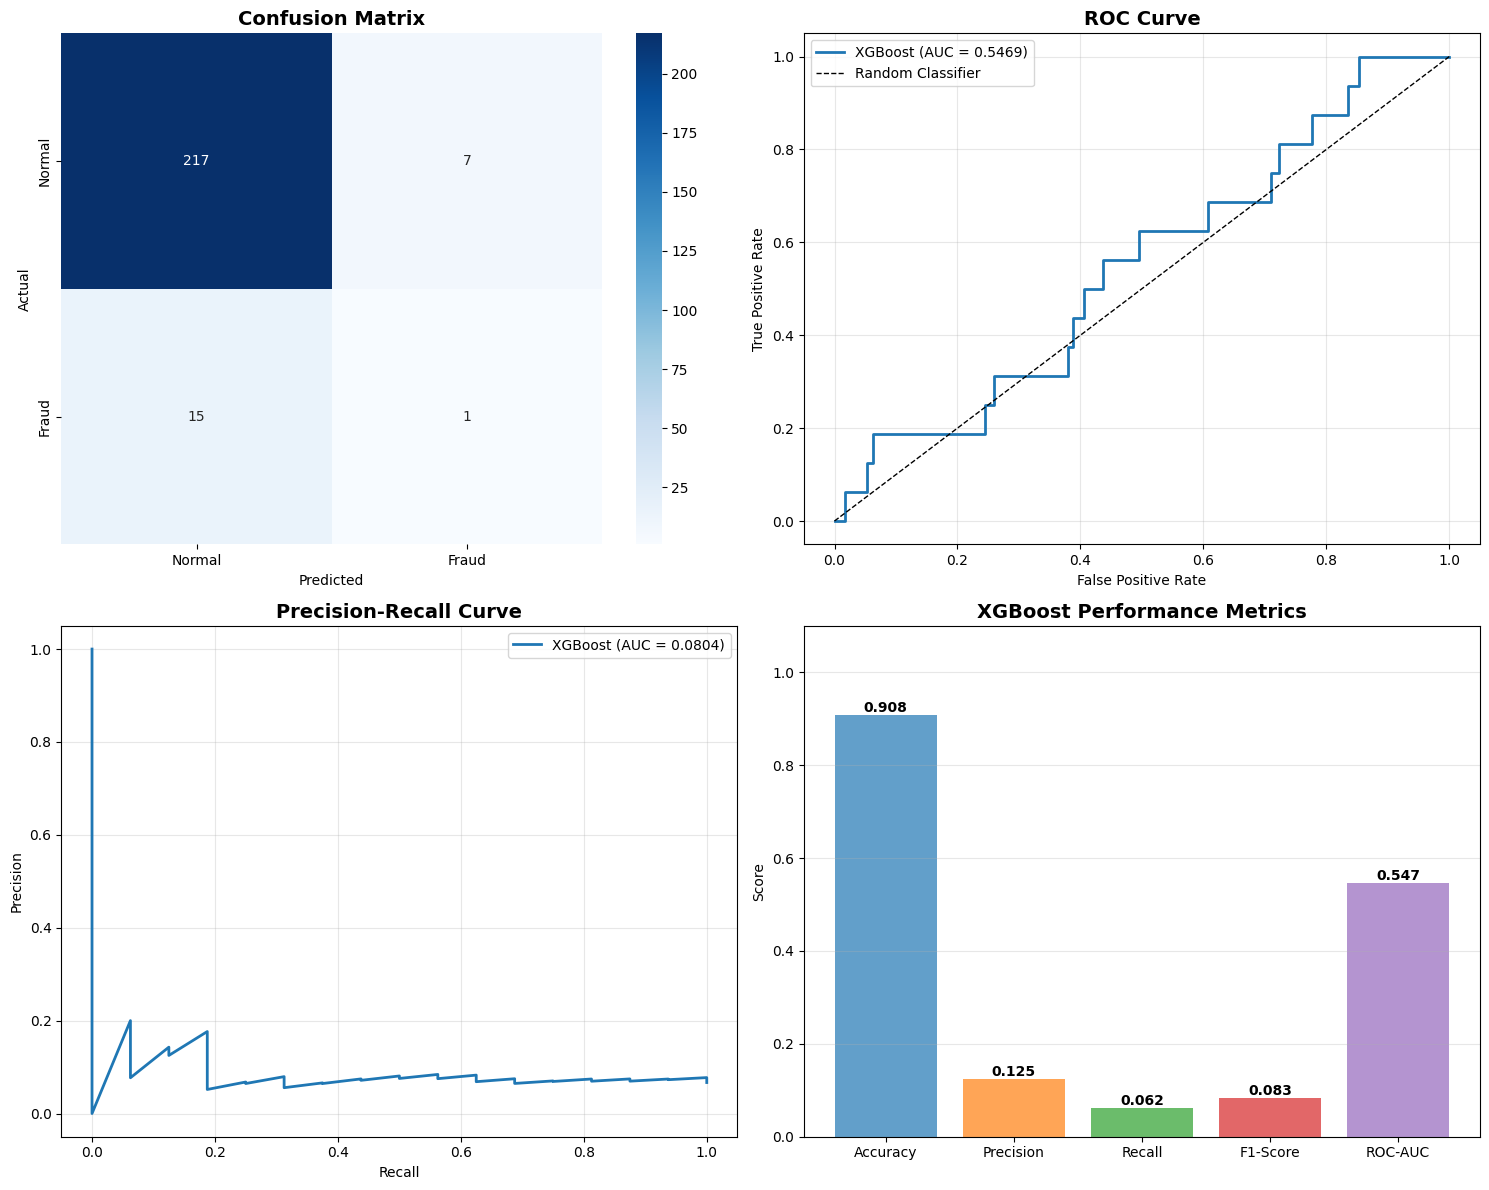

 Visualizations created and saved


In [56]:
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0, 0])
axes[0, 0].set_title('Confusion Matrix', fontsize=14, fontweight='bold')
axes[0, 0].set_ylabel('Actual')
axes[0, 0].set_xlabel('Predicted')
axes[0, 0].set_xticklabels(['Normal', 'Fraud'])
axes[0, 0].set_yticklabels(['Normal', 'Fraud'])

fpr, tpr, _ = roc_curve(y_test, y_pred_proba_optimized)
axes[0, 1].plot(fpr, tpr, linewidth=2, label=f'XGBoost (AUC = {roc_auc:.4f})')
axes[0, 1].plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier')
axes[0, 1].set_xlabel('False Positive Rate')
axes[0, 1].set_ylabel('True Positive Rate')
axes[0, 1].set_title('ROC Curve', fontsize=14, fontweight='bold')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

precision_curve, recall_curve, _ = precision_recall_curve(y_test, y_pred_proba_optimized)
pr_auc = auc(recall_curve, precision_curve)
axes[1, 0].plot(recall_curve, precision_curve, linewidth=2, label=f'XGBoost (AUC = {pr_auc:.4f})')
axes[1, 0].set_xlabel('Recall')
axes[1, 0].set_ylabel('Precision')
axes[1, 0].set_title('Precision-Recall Curve', fontsize=14, fontweight='bold')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
metrics_values = [accuracy, precision, recall, f1, roc_auc]
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']
bars = axes[1, 1].bar(metrics_names, metrics_values, color=colors, alpha=0.7)
axes[1, 1].set_ylabel('Score')
axes[1, 1].set_title('XGBoost Performance Metrics', fontsize=14, fontweight='bold')
axes[1, 1].set_ylim([0, 1.1])
axes[1, 1].grid(True, alpha=0.3, axis='y')

for bar in bars:
    height = bar.get_height()
    axes[1, 1].text(bar.get_x() + bar.get_width()/2., height,
                    f'{height:.3f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig('xgboost_performance.png', dpi=300, bbox_inches='tight')
plt.show()

print(" Visualizations created and saved")

## 10. Feature Importance Analysis

In [57]:
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': xgb_optimized.feature_importances_
}).sort_values('importance', ascending=False)

print("Top 20 Most Important Features:")
print(feature_importance.head(20))

Top 20 Most Important Features:
                 feature  importance
14              is_night    0.307002
13            is_weekend    0.143693
1                channel    0.123762
25       urgency_numeric    0.043453
8            slm_urgency    0.041999
21      is_risky_country    0.039245
7         slm_risk_score    0.035010
0                country    0.028020
24  composite_risk_score    0.027762
22      low_device_trust    0.024877
9   slm_anomaly_category    0.019561
17   txn_dayofweek_count    0.018593
4     device_trust_score    0.018415
5   num_txn_24h_customer    0.015647
15       txn_gap_minutes    0.013670
2      merchant_category    0.012323
3                 amount    0.011669
10              txn_hour    0.011125
19   customer_std_amount    0.010443
20     amount_z_customer    0.009895


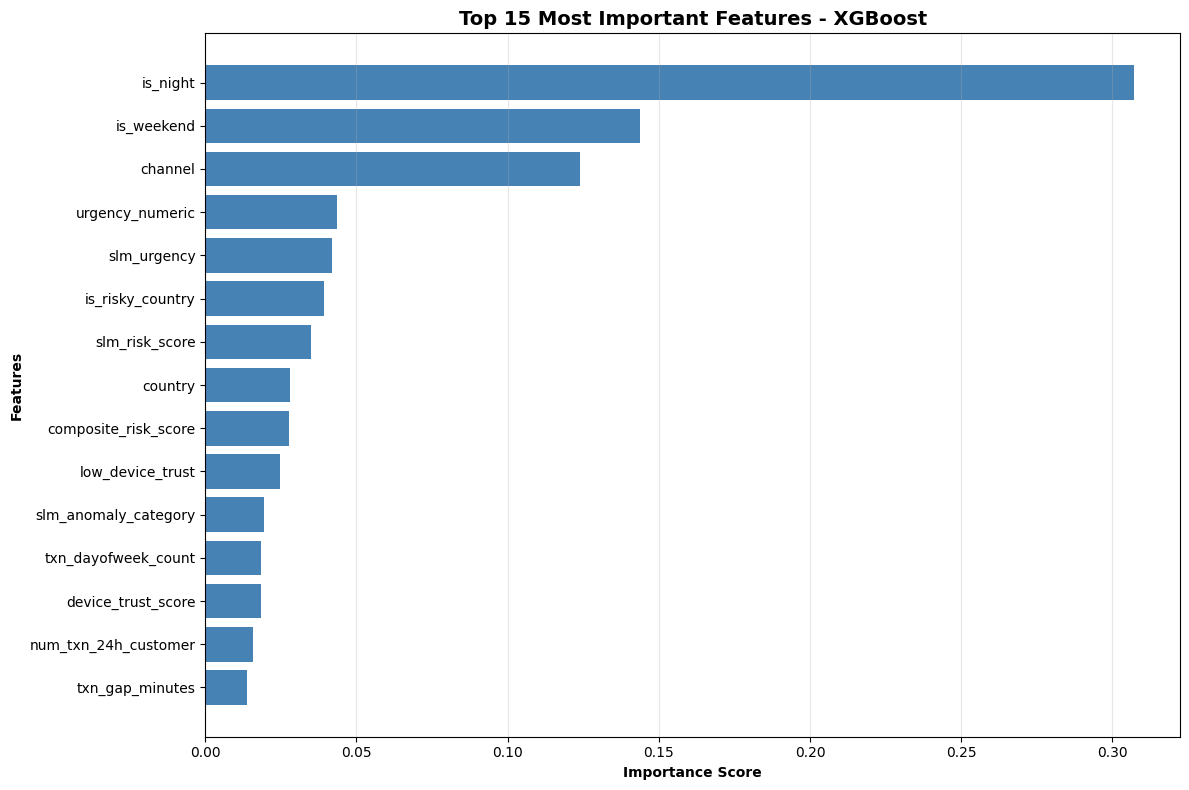

 Feature importance visualization saved


In [58]:
# Visualize top 15 feature importances
plt.figure(figsize=(12, 8))
top_features = feature_importance.head(15)
plt.barh(range(len(top_features)), top_features['importance'], color='steelblue')
plt.yticks(range(len(top_features)), top_features['feature'])
plt.xlabel('Importance Score', fontweight='bold')
plt.ylabel('Features', fontweight='bold')
plt.title('Top 15 Most Important Features - XGBoost', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig('xgboost_feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()

print(" Feature importance visualization saved")

## 11. Model Summary

In [59]:
print("=" * 60)
print("XGBOOST FRAUD DETECTION MODEL - FINAL SUMMARY")
print("=" * 60)

print(f"\nDataset Information:")
print(f"  Total samples: {len(df)}")
print(f"  Training samples: {len(X_train_smote)} (after SMOTE)")
print(f"  Test samples: {len(X_test)}")
print(f"  Number of features: {X.shape[1]}")

print(f"\nBest Hyperparameters:")
for param, value in grid_search.best_params_.items():
    print(f"  {param}: {value}")

print(f"\nPerformance Metrics:")
print(f"  Accuracy:  {accuracy:.4f}")
print(f"  Precision: {precision:.4f}")
print(f"  Recall:    {recall:.4f}")
print(f"  F1-Score:  {f1:.4f}")
print(f"  ROC-AUC:   {roc_auc:.4f}")

print(f"\nCross-Validation:")
print(f"  Mean F1 Score: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")

print(f"\nTop 5 Most Important Features:")
for idx, row in feature_importance.head(5).iterrows():
    print(f"  {row['feature']}: {row['importance']:.4f}")

print("\n" + "=" * 60)
print(" XGBoost model development complete!")
print("=" * 60)

XGBOOST FRAUD DETECTION MODEL - FINAL SUMMARY

Dataset Information:
  Total samples: 1200
  Training samples: 1790 (after SMOTE)
  Test samples: 240
  Number of features: 26

Best Hyperparameters:
  colsample_bytree: 1.0
  gamma: 0
  learning_rate: 0.3
  max_depth: 7
  min_child_weight: 1
  n_estimators: 300
  subsample: 0.8

Performance Metrics:
  Accuracy:  0.9083
  Precision: 0.1250
  Recall:    0.0625
  F1-Score:  0.0833
  ROC-AUC:   0.5469

Cross-Validation:
  Mean F1 Score: 0.9613 (+/- 0.0097)

Top 5 Most Important Features:
  is_night: 0.3070
  is_weekend: 0.1437
  channel: 0.1238
  urgency_numeric: 0.0435
  slm_urgency: 0.0420

 XGBoost model development complete!


In [60]:
# Save XGBoost metrics for model comparison
import os
import pandas as pd
from sklearn.metrics import average_precision_score

OUTPUT_DIR = "../outputs"
TAB_DIR = os.path.join(OUTPUT_DIR, "tables")
os.makedirs(TAB_DIR, exist_ok=True)

metrics_rows = [
    {
        "model": "XGBoost_baseline",
        "accuracy": accuracy_score(y_test, y_pred_baseline),
        "precision": precision_score(y_test, y_pred_baseline, zero_division=0),
        "recall": recall_score(y_test, y_pred_baseline, zero_division=0),
        "f1": f1_score(y_test, y_pred_baseline, zero_division=0),
        "roc_auc": roc_auc_score(y_test, y_pred_proba_baseline),
        "pr_auc": average_precision_score(y_test, y_pred_proba_baseline),
    },
    {
        "model": "XGBoost_tuned",
        "accuracy": accuracy_score(y_test, y_pred_optimized),
        "precision": precision_score(y_test, y_pred_optimized, zero_division=0),
        "recall": recall_score(y_test, y_pred_optimized, zero_division=0),
        "f1": f1_score(y_test, y_pred_optimized, zero_division=0),
        "roc_auc": roc_auc_score(y_test, y_pred_proba_optimized),
        "pr_auc": average_precision_score(y_test, y_pred_proba_optimized),
    },
]

metrics_df = pd.DataFrame(metrics_rows)
metrics_path = os.path.join(TAB_DIR, "metrics_xgboost.csv")
metrics_df.to_csv(metrics_path, index=False)
print("Saved:", metrics_path)

metrics_df


Saved: ../outputs/tables/metrics_xgboost.csv


,model,accuracy,precision,recall,f1,roc_auc,pr_auc
0,XGBoost_baseline,0.912500,0.000,0.0000,0.000000,0.578962,0.083527
1,XGBoost_tuned,0.908333,0.125,0.0625,0.083333,0.546875,0.093735


In [61]:
# Export XGBoost feature importance for interpretation
import os
import pandas as pd

OUTPUT_DIR = '../outputs'
TAB_DIR = os.path.join(OUTPUT_DIR, 'tables')
os.makedirs(TAB_DIR, exist_ok=True)

xgb_fi = pd.DataFrame({
    'feature': X.columns,
    'importance': xgb_optimized.feature_importances_
}).sort_values('importance', ascending=False)

fi_path = os.path.join(TAB_DIR, 'xgboost_feature_importance.csv')
xgb_fi.to_csv(fi_path, index=False)
print('Saved:', fi_path)
display(xgb_fi.head(15))


Saved: ../outputs/tables/xgboost_feature_importance.csv


,feature,importance
14,is_night,0.307002
13,is_weekend,0.143693
1,channel,0.123762
25,urgency_numeric,0.043453
8,slm_urgency,0.041999
21,is_risky_country,0.039245
7,slm_risk_score,0.035010
0,country,0.028020
24,composite_risk_score,0.027762
22,low_device_trust,0.024877
